In [ ]:
from google.colab import files

uploaded = files.upload()

Saving news_dataset.csv to news_dataset (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

In [ ]:
df = pd.read_csv('/content/news_dataset.csv')

df.head()

,title,text,subject,date,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,News,"November 13, 2016",0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,worldnews,"September 13, 2017",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,politics,"Feb 16, 2017",0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,politics,"Nov 15, 2015",0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,politicsNews,"September 13, 2016",1


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Shape: (6000, 5)

Columns:
Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    6000 non-null   object
 1   text     6000 non-null   object
 2   subject  6000 non-null   object
 3   date     6000 non-null   object
 4   label    6000 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 234.5+ KB


In [ ]:
print(df['label'].value_counts())

label
0    3000
1    3000
Name: count, dtype: int64


In [ ]:
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')

df['content'] = df['title'] + ' ' + df['text']

df = df.dropna(subset=['label'])

df[['content', 'label']].head()

,content,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,0
1,"China backs U.N. call for justice in Yemen, U....",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,0
4,Lawmakers aim to delay U.S. ceding control of ...,1


In [ ]:
X = df['content']
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4800
Testing samples: 1200


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4800, 5000)
Testing TF-IDF shape: (1200, 5000)


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_tfidf)

y_prob = model.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
from sklearn.metrics import log_loss

cost = log_loss(y_test, y_prob)

print("Log Loss (Cost Function):", cost)

Log Loss (Cost Function): 0.17765490449966226


Confusion Matrix:
[[579  21]
 [ 13 587]]


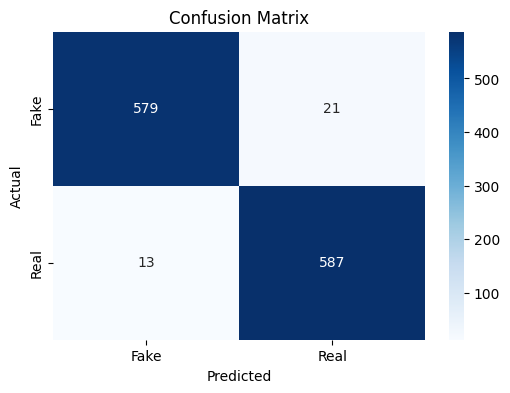

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9716666666666667
Precision: 0.9654605263157895
Recall   : 0.9783333333333334
F1-Score : 0.9718543046357616


In [ ]:
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")

Accuracy : 97.17%
Precision: 96.55%
Recall   : 97.83%
F1-Score : 97.19%


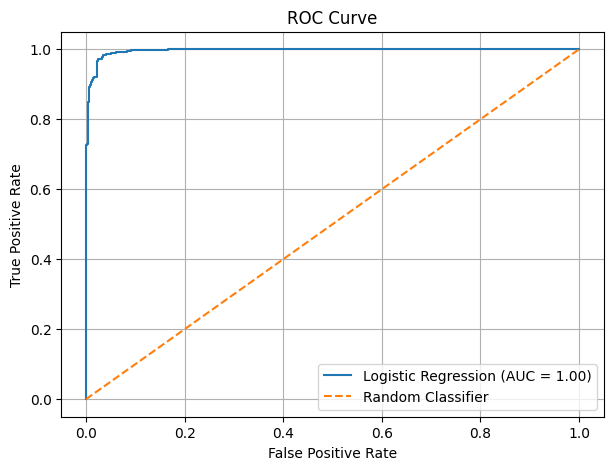

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

In [ ]:
print(f"AUC Score: {roc_auc:.4f}")

AUC Score: 0.9961


In [ ]:
news = ["Scientists discover a new technology that could help reduce pollution"]

news_tfidf = vectorizer.transform(news)

prediction = model.predict(news_tfidf)[0]
probability = model.predict_proba(news_tfidf)[0]

if prediction == 0:
    print("Prediction: FAKE NEWS")
else:
    print("Prediction: REAL NEWS")

print("Fake probability:", probability[0])
print("Real probability:", probability[1])

Prediction: REAL NEWS
Fake probability: 0.4980254961945969
Real probability: 0.5019745038054031
